# Building Quantum Hamiltonians

This notebook demonstrates how to construct various quantum many-body Hamiltonians using the ShadowGPT physics module.

## Setup and Imports

First, let's import the necessary modules and set up our environment.

In [11]:
# Add the parent directory to Python path for development
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
from shadowgpt import physics
import matplotlib.pyplot as plt
import numpy as np

## Transverse Field Ising Model (TFIM)

The TFIM is one of the most studied quantum many-body models:

$$H = -(1-g) \sum_{i=1}^{n-1} Z_i Z_{i+1} - g \sum_{i=1}^n X_i$$

Where:
- $g$ is a single parameter to control the relative strength between Ising coupling and transverse field.
- $Z_i$ and $X_i$ are Pauli operators on site $i$.

This creates a Hamiltonian object that we can then convert to different representations (dense matrix, MPO, etc.).

In [2]:
from shadowgpt import physics
ham = physics.ham_tf_ising(n=3, gs=0.2, bc="open")
ham

Hamiltonian(H=-0.20 X2 - 0.80 Z1 Z2 - 0.20 X1 - 0.80 Z0 Z1 - 0.20 X0)

Dense matrix representation

In [3]:
ham.to_numpy().real

array([[-1.6, -0.2, -0.2,  0. , -0.2,  0. ,  0. ,  0. ],
       [-0.2,  0. ,  0. , -0.2,  0. , -0.2,  0. ,  0. ],
       [-0.2,  0. ,  1.6, -0.2,  0. ,  0. , -0.2,  0. ],
       [ 0. , -0.2, -0.2,  0. ,  0. ,  0. ,  0. , -0.2],
       [-0.2,  0. ,  0. ,  0. ,  0. , -0.2, -0.2,  0. ],
       [ 0. , -0.2,  0. ,  0. , -0.2,  1.6,  0. , -0.2],
       [ 0. ,  0. , -0.2,  0. , -0.2,  0. ,  0. , -0.2],
       [ 0. ,  0. ,  0. , -0.2,  0. , -0.2, -0.2, -1.6]])

MPO representation

In [4]:
mpo = ham.to_MPO()
mpo.show()


│3│3│
●─<─<
│ │ │


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cotengra/hyperoptimizers/hyper.py:55: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization. It is recommended to install one of these libraries for higher quality contraction paths.
  warnings.warn(


Verify that the MPO construction is mathematically correct by converting it to dense matrix.

In [5]:
mpo.to_dense().round(12).real

array([[-1.6, -0.2, -0.2,  0. , -0.2,  0. ,  0. ,  0. ],
       [-0.2, -0. ,  0. , -0.2,  0. , -0.2,  0. ,  0. ],
       [-0.2,  0. ,  1.6, -0.2, -0. , -0. , -0.2,  0. ],
       [ 0. , -0.2, -0.2, -0. ,  0. , -0. ,  0. , -0.2],
       [-0.2,  0. ,  0. ,  0. ,  0. , -0.2, -0.2,  0. ],
       [ 0. , -0.2,  0. ,  0. , -0.2,  1.6,  0. , -0.2],
       [-0. , -0. , -0.2,  0. , -0.2,  0. , -0. , -0.2],
       [ 0. , -0. ,  0. , -0.2,  0. , -0.2, -0.2, -1.6]])

One can see that the MPO compression didn't introduce significant errors. Both MPO and dense matrix representations describe the same physical Hamiltonian.

## Cluster-Ising Model

The Cluster-Ising model is a quantum many-body system with Z2 × Z2 symmetry that exhibits rich phase transitions:

$$H = -g_1 \sum_{i} Z_{i-1}Z_{i+1} - g_2 \sum_{i} X_i - g_3 \sum_{i} Z_{i-1}X_iZ_{i+1}$$

Where:
- $g_1, g_2, g_3$ are coupling strengths with $g_1 + g_2 + g_3 = 1$ and $g_i > 0$
- The model has three distinct terms: Ising coupling, transverse field, and cluster interaction
- This model can undergo quantum phase transitions between different symmetry-broken phases


### Basic Cluster-Ising Hamiltonian Construction

Let's create a Cluster-Ising Hamiltonian with balanced coupling strengths:


In [22]:
# Create Cluster-Ising Hamiltonian with balanced couplings
# g1=0.4 (Ising), g2=0.3 (transverse field), g3=0.3 (cluster)
ham_cluster = physics.ham_cluster_ising(n=6, gs=[0.4, 0.3, 0.3], bc="open")
print("Cluster-Ising Hamiltonian:")
print(ham_cluster)
print(f"Number of qubits: {ham_cluster.H.N}")
print(f"Number of terms: {len(ham_cluster.H)}")


Cluster-Ising Hamiltonian:
Hamiltonian(H=-0.30 X5 - 0.30 X4 - 0.40 Z3 Z5 - 0.30 Z3 X4 Z5 - 0.30 X3 - 0.40 Z2 Z4 - 0.30 Z2 X3 Z4 - 0.30 X2 - 0.40 Z1 Z3 - 0.30 Z1 X2 Z3 - 0.30 X1 - 0.40 Z0 Z2 - 0.30 Z0 X1 Z2 - 0.30 X0)
Number of qubits: 6
Number of terms: 14


### Examine Hamiltonian Terms

Let's look at the individual terms in the Cluster-Ising Hamiltonian:


In [23]:
# Display all terms in the Hamiltonian
print("Hamiltonian terms:")
for i, term in enumerate(ham_cluster.H):
    print(f"Term {i+1}: {term}")


Hamiltonian terms:
Term 1: -0.30 X5
Term 2: -0.30 X4
Term 3: -0.40 Z3 Z5
Term 4: -0.30 Z3 X4 Z5
Term 5: -0.30 X3
Term 6: -0.40 Z2 Z4
Term 7: -0.30 Z2 X3 Z4
Term 8: -0.30 X2
Term 9: -0.40 Z1 Z3
Term 10: -0.30 Z1 X2 Z3
Term 11: -0.30 X1
Term 12: -0.40 Z0 Z2
Term 13: -0.30 Z0 X1 Z2
Term 14: -0.30 X0


### Dense Matrix Representation


Matrix shape: (64, 64)
Matrix is Hermitian: True


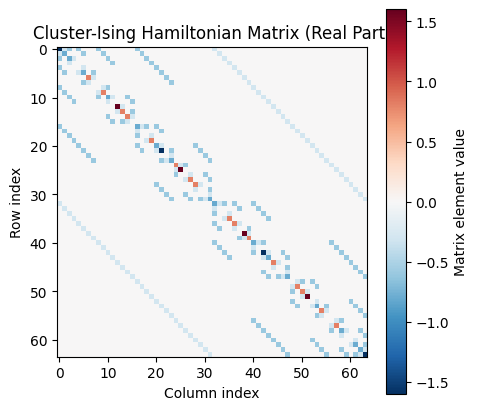

In [24]:
# Convert to dense matrix
matrix_cluster = ham_cluster.to_numpy()
print(f"Matrix shape: {matrix_cluster.shape}")
print(f"Matrix is Hermitian: {np.allclose(matrix_cluster, matrix_cluster.conj().T)}")

# Plot the matrix as an image
plt.figure(figsize=(5, 5))
plt.imshow(matrix_cluster.real, cmap='RdBu_r', aspect='equal')
plt.colorbar(label='Matrix element value')
plt.title('Cluster-Ising Hamiltonian Matrix (Real Part)')
plt.xlabel('Column index')
plt.ylabel('Row index')
plt.show()


### MPO Representation


In [25]:
# Convert to MPO
mpo_cluster = ham_cluster.to_MPO()
print("MPO representation:")
mpo_cluster.show()


MPO representation:
│3│4│4│4│3│
●─<─<─<─<─<
│ │ │ │ │ │


Let's verify that the MPO representation is mathematically equivalent to the dense matrix:

MPO converted to dense matrix:


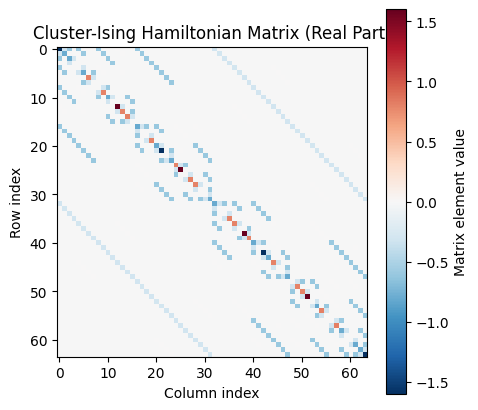


Difference between direct and MPO-derived matrices:
Max difference: 9.58e-15
Mean difference: 4.12e-16
Matrices are equivalent: True


In [26]:
# Convert MPO back to dense matrix and compare
mpo_dense = mpo_cluster.to_dense()
print("MPO converted to dense matrix:")

# Plot the matrix as an image
plt.figure(figsize=(5, 5))
plt.imshow(mpo_dense.real, cmap='RdBu_r', aspect='equal')
plt.colorbar(label='Matrix element value')
plt.title('Cluster-Ising Hamiltonian Matrix (Real Part)')
plt.xlabel('Column index')
plt.ylabel('Row index')
plt.show()

print(f"\nDifference between direct and MPO-derived matrices:")
diff = np.abs(matrix_cluster - mpo_dense)
print(f"Max difference: {diff.max():.2e}")
print(f"Mean difference: {diff.mean():.2e}")
print(f"Matrices are equivalent: {np.allclose(matrix_cluster, mpo_dense, atol=1e-12)}")
